# Olist Brazilian E-Commerce: Customer, Delivery & Review Analytics with Machine Learning

**Author:** Siddu Varikuppala  
**Programme:** AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 (BharatCares)  
**Dataset:** Brazilian E-Commerce Public Dataset by Olist — [Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

## Problem Statement
Olist is a Brazilian marketplace platform. Understanding what drives poor customer reviews—
especially whether late delivery is a key predictor—can directly improve customer satisfaction
and seller performance management.

## Objectives
1. Understand sales trends, delivery performance and customer review behaviour.
2. Statistically test whether late deliveries cause lower review scores.
3. Segment customers using RFM scoring and KMeans clustering.
4. Build a machine-learning model that predicts whether an order will receive a low review
   (score ≤ 2) **without** using any review-derived feature (no data leakage).
5. Translate findings into actionable business recommendations.

## Notebook Structure
| Section | Content |
|---------|---------|
| A | Imports & setup |
| B | Data loading |
| C | Data quality audit |
| D | Data cleaning |
| E | Feature engineering |
| F | EDA with visualisations |
| G | Statistical testing |
| H | Customer segmentation (RFM + KMeans) |
| I | Machine learning |
| J | Business insights |
| K | Limitations & future work |


## A. Imports & Setup


In [1]:
# -*- coding: utf-8 -*-
import sys, warnings, os, json, time
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import scipy.stats as stats
from scipy.stats import mannwhitneyu, chi2_contingency, shapiro
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import xgboost as xgb
import joblib
import shap

plt.rcParams.update({'figure.dpi':100,'font.size':11,'axes.titlesize':13,
                     'axes.labelsize':11,'figure.figsize':(10,5)})
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
FIG_DIR  = 'outputs/figures'
DATA_DIR = 'data'
os.makedirs(FIG_DIR,  exist_ok=True)
os.makedirs('models', exist_ok=True)

print("Python version:", sys.version.split()[0])
print("Imports OK")
print(f"Figures -> {FIG_DIR}/")


Python version: 3.11.9
Imports OK
Figures -> outputs/figures/


## B. Data Loading

We load all eight tables from the `data/` folder (geolocation is skipped — it is not
needed for any analysis in this notebook).  
For each table we print shape, dtypes, head and memory usage.


In [2]:
DATA = 'data'
orders      = pd.read_csv(f'{DATA}/olist_orders_dataset.csv')
items       = pd.read_csv(f'{DATA}/olist_order_items_dataset.csv')
payments    = pd.read_csv(f'{DATA}/olist_order_payments_dataset.csv')
reviews     = pd.read_csv(f'{DATA}/olist_order_reviews_dataset.csv')
customers   = pd.read_csv(f'{DATA}/olist_customers_dataset.csv')
products    = pd.read_csv(f'{DATA}/olist_products_dataset.csv')
sellers     = pd.read_csv(f'{DATA}/olist_sellers_dataset.csv')
translation = pd.read_csv(f'{DATA}/product_category_name_translation.csv')
# geolocation skipped – not used in downstream analysis

tables = {
    'orders': orders, 'items': items, 'payments': payments,
    'reviews': reviews, 'customers': customers,
    'products': products, 'sellers': sellers, 'translation': translation
}

print(f"{'Table':<20} {'Rows':>8} {'Cols':>6}  {'Memory':>10}")
print("-" * 50)
for name, df in tables.items():
    mem = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  {name:<18} {len(df):>8,} {len(df.columns):>6}  {mem:>8.2f} MB")


Table                    Rows   Cols      Memory
--------------------------------------------------
  orders               99,441      8     21.95 MB
  items               112,650      7     18.37 MB
  payments            103,886      5      8.11 MB
  reviews              99,224      7     17.84 MB
  customers            99,441      5     11.03 MB
  products             32,951      9      3.73 MB
  sellers               3,095      4      0.22 MB
  translation              71      2      0.00 MB


In [3]:
# Sample dtypes and head for orders table (representative)
print("orders dtypes:")
print(orders.dtypes.to_string())
print()
orders.head(3)


orders dtypes:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


## C. Data Quality Audit (Before Cleaning)

We check missing values, duplicate rows, multiple reviews per order and type issues
**before** making any changes so we can log before/after counts in the next section.


In [4]:
print("=== Missing Values ===")
missing_summary = {}
for name, df in tables.items():
    miss     = df.isnull().sum()
    miss_pct = (miss / len(df) * 100).round(2)
    has_miss = miss[miss > 0]
    if len(has_miss):
        missing_summary[name] = has_miss.to_dict()
        print(f"\n  {name}:")
        for col, cnt in has_miss.items():
            print(f"    {col}: {cnt:,}  ({miss_pct[col]:.1f}%)")
    else:
        print(f"  {name}: no missing values")

print("\n=== Duplicate Rows ===")
for name, df in tables.items():
    n = df.duplicated().sum()
    print(f"  {name}: {n:,}")

print(f"\n  Orders with >1 review: {reviews.groupby('order_id').size().gt(1).sum():,}")


=== Missing Values ===

  orders:
    order_approved_at: 160  (0.2%)
    order_delivered_carrier_date: 1,783  (1.8%)
    order_delivered_customer_date: 2,965  (3.0%)
  items: no missing values
  payments: no missing values

  reviews:
    review_comment_title: 87,656  (88.3%)
    review_comment_message: 58,247  (58.7%)
  customers: no missing values

  products:
    product_category_name: 610  (1.9%)
    product_name_lenght: 610  (1.9%)
    product_description_lenght: 610  (1.9%)
    product_photos_qty: 610  (1.9%)
    product_weight_g: 2  (0.0%)
    product_length_cm: 2  (0.0%)
    product_height_cm: 2  (0.0%)
    product_width_cm: 2  (0.0%)
  sellers: no missing values
  translation: no missing values

=== Duplicate Rows ===
  orders: 0


  items: 0


  payments: 0


  reviews: 0
  customers: 0
  products: 0
  sellers: 0
  translation: 0



  Orders with >1 review: 547


In [5]:
# Missing-value % bar chart
all_miss = {
    f"{name}.{col}": round(cnt / len(tables[name]) * 100, 1)
    for name, d in missing_summary.items()
    for col, cnt in d.items()
}
cols_sorted = sorted(all_miss, key=all_miss.get, reverse=True)
fig, ax = plt.subplots(figsize=(12, max(4, len(cols_sorted)*0.38)))
ax.barh(cols_sorted, [all_miss[c] for c in cols_sorted], color='#e05c5c')
ax.set_xlabel('Missing %')
ax.set_title('Figure 0: Missing Values (%) Before Cleaning')
ax.axvline(5, ls='--', color='gray', alpha=0.5, label='5% threshold')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/00_missing_values.png', bbox_inches='tight')
plt.close()
print("Saved: 00_missing_values.png")


Saved: 00_missing_values.png


## D. Data Cleaning

Each action is logged with before/after row counts so we can report exact numbers
in the report and README.

**Decisions:**
- **Duplicate rows:** `drop_duplicates()` — zero found, but we run it defensively.
- **Multiple reviews per order (547 cases):** keep the row with the *latest* `review_creation_date`
  to avoid leaking multiple signals about the same order.
- **Date columns:** convert to `datetime64` for arithmetic.
- **`product_category_name` NaN (610 rows):** fill with `'unknown'` — we translate to English
  next; dropping would lose product info.
- **Weight/dimension NaNs (2 rows each):** fill with column median — used only for potential
  freight modelling; tiny share.
- **Orders with no `order_delivered_customer_date`:** *not* dropped here; excluded only from
  delivery-time analysis downstream.
- **IQR capping (1st–99th percentile)** on `total_price` and `total_freight` to suppress the
  ~1% extreme outliers without losing rows.


In [6]:
cleaning_log = []

def log(table, action, before, after):
    cleaning_log.append({'table':table,'action':action,
                         'before':before,'removed':before-after,'after':after})
    print(f"  [{table}] {action}: {before:,} -> {after:,}  (removed {before-after:,})")

# 1. Drop duplicate rows
for name in ['orders','items','payments','reviews','customers','products','sellers']:
    df = tables[name]; b = len(df)
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    log(name, 'drop_duplicates', b, len(df))
    tables[name] = df

orders=tables['orders']; items=tables['items']; payments=tables['payments']
reviews=tables['reviews']; customers=tables['customers']
products=tables['products']; sellers=tables['sellers']

# 2. Keep latest review per order
b = len(reviews)
reviews['review_creation_date'] = pd.to_datetime(reviews['review_creation_date'], errors='coerce')
reviews = (reviews.sort_values('review_creation_date', ascending=False)
           .drop_duplicates(subset='order_id', keep='first').reset_index(drop=True))
log('reviews', 'keep_latest_review_per_order', b, len(reviews))

# 3. Date columns -> datetime
for tbl_name, cols in {
    'orders':  ['order_purchase_timestamp','order_approved_at',
                'order_delivered_carrier_date','order_delivered_customer_date',
                'order_estimated_delivery_date'],
    'items':   ['shipping_limit_date'],
    'reviews': ['review_creation_date','review_answer_timestamp'],
}.items():
    for col in cols:
        if col in tables[tbl_name].columns:
            tables[tbl_name][col] = pd.to_datetime(tables[tbl_name][col], errors='coerce')
orders=tables['orders']; items=tables['items']; reviews=tables['reviews']
print("  Date columns -> datetime OK")

# 4. Fill missing
products['product_category_name'] = products['product_category_name'].fillna('unknown')
for col in ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']:
    products[col] = products[col].fillna(products[col].median())
print("  products: category NaN->'unknown', dims -> median")

# 5. Translate category names
products = products.merge(translation, on='product_category_name', how='left')
products['product_category_name_english'] = (
    products['product_category_name_english'].fillna(products['product_category_name']))
print(f"  Categories: {products['product_category_name_english'].nunique()} unique EN")

# 6. Aggregate items per order (prevent row multiplication)
items_agg = items.groupby('order_id').agg(
    total_price=('price','sum'), total_freight=('freight_value','sum'),
    num_items=('order_item_id','count'), seller_id=('seller_id','first'),
    product_id=('product_id','first')).reset_index()

# 7. Aggregate payments per order
pay_agg = payments.groupby('order_id').agg(
    payment_value=('payment_value','sum'),
    payment_type=('payment_type', lambda x: x.mode().iloc[0] if len(x) else 'unknown'),
    payment_installments=('payment_installments','max')).reset_index()

# 8. Build master
master = orders.merge(customers[['customer_id','customer_state']], on='customer_id', how='left')
master = master.merge(items_agg,   on='order_id', how='left')
master = master.merge(pay_agg,     on='order_id', how='left')
master = master.merge(reviews[['order_id','review_score']], on='order_id', how='left')
master = master.merge(products[['product_id','product_category_name_english']], on='product_id', how='left')
master = master.merge(sellers[['seller_id','seller_state']], on='seller_id', how='left')
print(f"  master shape: {master.shape}")

# 9. IQR capping
for col, lbl in [('total_price','total_price'),('total_freight','total_freight')]:
    master[col] = master[col].fillna(0)
    q1, q99 = master[col].quantile(0.01), master[col].quantile(0.99)
    master[col] = master[col].clip(q1, q99)
    print(f"  IQR cap [{lbl}]: [{q1:.2f}, {q99:.2f}]")

master.to_csv(f'{DATA}/cleaned_master.csv', index=False)
print(f"  Saved: data/cleaned_master.csv  ({master.shape[0]:,} x {master.shape[1]})")


  [orders] drop_duplicates: 99,441 -> 99,441  (removed 0)
  [items] drop_duplicates: 112,650 -> 112,650  (removed 0)
  [payments] drop_duplicates: 103,886 -> 103,886  (removed 0)


  [reviews] drop_duplicates: 99,224 -> 99,224  (removed 0)


  [customers] drop_duplicates: 99,441 -> 99,441  (removed 0)
  [products] drop_duplicates: 32,951 -> 32,951  (removed 0)
  [sellers] drop_duplicates: 3,095 -> 3,095  (removed 0)
  [reviews] keep_latest_review_per_order: 99,224 -> 98,673  (removed 551)


  Date columns -> datetime OK
  products: category NaN->'unknown', dims -> median
  Categories: 74 unique EN


  master shape: (99992, 20)
  IQR cap [total_price]: [7.90, 997.82]
  IQR cap [total_freight]: [0.00, 104.73]


  Saved: data/cleaned_master.csv  (99,992 x 20)


In [7]:
# Cleaning log summary
print("Cleaning log:")
for rec in cleaning_log:
    print(f"  {rec['table']:<12} {rec['action']:<35} removed={rec['removed']:,}")


Cleaning log:
  orders       drop_duplicates                     removed=0
  items        drop_duplicates                     removed=0
  payments     drop_duplicates                     removed=0
  reviews      drop_duplicates                     removed=0
  customers    drop_duplicates                     removed=0
  products     drop_duplicates                     removed=0
  sellers      drop_duplicates                     removed=0
  reviews      keep_latest_review_per_order        removed=551


## E. Feature Engineering

| New Column | Formula | Purpose |
|---|---|---|
| `delivery_days` | delivered − purchase (days) | Core delivery KPI |
| `estimated_vs_actual_delay_days` | delivered − estimated (days) | Signed delay; +ve = late |
| `is_late` | delay_days > 0 | Binary flag for statistical tests & ML |
| `purchase_month/weekday/hour` | from `order_purchase_timestamp` | Temporal patterns |
| `freight_ratio` | total_freight / total_price | Relative shipping cost |
| `low_review` | review_score ≤ 2 | **Target variable** (no data leakage) |

Rare product categories (< 100 orders) are collapsed to `'other'` to reduce cardinality.


In [8]:
df = master.copy()
for col in ['order_purchase_timestamp','order_delivered_customer_date',
            'order_estimated_delivery_date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

df['delivery_days']                  = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['estimated_days']                 = (df['order_estimated_delivery_date']  - df['order_purchase_timestamp']).dt.days
df['estimated_vs_actual_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_late']        = (df['estimated_vs_actual_delay_days'] > 0).astype(int)
df['purchase_month'] = df['order_purchase_timestamp'].dt.month
df['purchase_weekday']= df['order_purchase_timestamp'].dt.dayofweek
df['purchase_hour']  = df['order_purchase_timestamp'].dt.hour
df['purchase_year']  = df['order_purchase_timestamp'].dt.year
df['freight_ratio']  = np.where(df['total_price']>0, df['total_freight']/df['total_price'], 0.0)

for col in ['num_items','payment_installments']:
    df[col] = df[col].fillna(1)
for col in ['payment_type','product_category_name_english','seller_state','customer_state']:
    df[col] = df[col].fillna('unknown')

# Target (no leakage: review_score is the source – never a model feature)
df['low_review'] = (df['review_score'] <= 2).astype(int)

# Collapse rare categories
cat_vc = df['product_category_name_english'].value_counts()
df['product_category_name_english'] = df['product_category_name_english'].replace(
    cat_vc[cat_vc < 100].index, 'other')

delivered = df[df['order_status']=='delivered'].copy()
del_data  = delivered['delivery_days'].dropna()

print(f"df shape:              {df.shape}")
print(f"delivered orders:      {len(delivered):,}")
print(f"delivery_days mean:    {del_data.mean():.1f}d  median: {del_data.median():.1f}d  max: {del_data.max():.0f}d")
print(f"is_late:               {delivered['is_late'].mean()*100:.1f}%")
print(f"low_review (score<=2): {delivered['low_review'].mean()*100:.1f}%")
print(f"product categories:    {df['product_category_name_english'].nunique()} unique")


df shape:              (99992, 30)
delivered orders:      97,007
delivery_days mean:    12.1d  median: 10.0d  max: 209d
is_late:               6.8%
low_review (score<=2): 12.7%
product categories:    53 unique


## F. Exploratory Data Analysis

> All figures are saved to `outputs/figures/`. Each chart is followed by 1–2 lines of insight.

### F1 – Monthly Revenue & Orders Trend


In [9]:
delivered['year_month'] = delivered['order_purchase_timestamp'].dt.to_period('M')
monthly = (delivered.groupby('year_month')
           .agg(revenue=('total_price','sum'), orders=('order_id','count'))
           .reset_index())
monthly['ym_str'] = monthly['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14,5))
ax2 = ax1.twinx()
ax1.bar(range(len(monthly)), monthly['revenue'], color='#4C9BE8', alpha=0.7, label='Revenue (R$)')
ax2.plot(range(len(monthly)), monthly['orders'], color='#E84C4C', marker='o', ms=4, label='Orders')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['ym_str'], rotation=45, ha='right', fontsize=8)
ax1.set_ylabel('Revenue (R$)'); ax2.set_ylabel('Number of Orders')
ax1.set_title('Figure 1: Monthly Revenue and Order Volume (Delivered Orders)')
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
h1,l1=ax1.get_legend_handles_labels(); h2,l2=ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_monthly_revenue_orders.png', bbox_inches='tight'); plt.close()
peak_m = monthly.loc[monthly['revenue'].idxmax(),'ym_str']
print(f"Peak month: {peak_m}  Revenue: R${monthly['revenue'].max():,.0f}")
print("INSIGHT: Strong growth through 2016-2017; November 2017 peak coincides with Black Friday/Cyber Monday.")


Peak month: 2017-11  Revenue: R$958,636
INSIGHT: Strong growth through 2016-2017; November 2017 peak coincides with Black Friday/Cyber Monday.


### F2 – Top 10 Categories by Revenue


In [10]:
top10 = (delivered.groupby('product_category_name_english')['total_price']
         .sum().sort_values(ascending=False).head(10).reset_index())
top10.columns = ['category','revenue']
fig, ax = plt.subplots(figsize=(10,6))
bars = ax.barh(top10['category'][::-1], top10['revenue'][::-1], color='#4C9BE8')
ax.set_xlabel('Total Revenue (R$)')
ax.set_title('Figure 2: Top 10 Product Categories by Revenue')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
for bar, val in zip(bars, top10['revenue'][::-1]):
    ax.text(bar.get_width()+2000, bar.get_y()+bar.get_height()/2,
            f'R${val/1e6:.2f}M', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_top10_categories_revenue.png', bbox_inches='tight'); plt.close()
print(f"#1 category: {top10.iloc[0]['category']}  R${top10.iloc[0]['revenue']:,.0f}")
print("INSIGHT: Health & beauty, watches and bed/bath/table top the revenue chart.")


#1 category: health_beauty  R$1,200,598
INSIGHT: Health & beauty, watches and bed/bath/table top the revenue chart.


### F3 – Orders by Weekday & Hour


In [11]:
wmap = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
delivered['weekday_name'] = delivered['purchase_weekday'].map(wmap)
wd = (delivered.groupby('weekday_name')['order_id'].count()
      .reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))
hr = delivered.groupby('purchase_hour')['order_id'].count()
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].bar(wd.index, wd.values, color='#7EC8A4')
axes[0].set_title('Figure 3a: Orders by Day of Week'); axes[0].set_xlabel('Day')
axes[1].plot(hr.index, hr.values, color='#E84C4C', marker='o', ms=4)
axes[1].fill_between(hr.index, hr.values, alpha=0.2, color='#E84C4C')
axes[1].set_title('Figure 3b: Orders by Hour'); axes[1].set_xlabel('Hour (0-23)')
axes[1].set_xticks(range(0,24,2))
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_orders_weekday_hour.png', bbox_inches='tight'); plt.close()
print(f"Busiest day: {wd.idxmax()}  Peak hour: {hr.idxmax()}:00")
print("INSIGHT: Monday is busiest; orders peak around 16:00 (4 pm) suggesting post-work browsing.")


Busiest day: Mon  Peak hour: 16:00
INSIGHT: Monday is busiest; orders peak around 16:00 (4 pm) suggesting post-work browsing.


### F4 – Payment Type Distribution


In [12]:
pay_dist = delivered['payment_type'].value_counts()
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(pay_dist.index, pay_dist.values,
       color=['#4C9BE8','#E84C4C','#7EC8A4','#F5A623','#9B59B6'][:len(pay_dist)])
ax.set_title('Figure 4: Payment Type Distribution')
ax.set_xlabel('Payment Type'); ax.set_ylabel('Orders')
for i,(k,v) in enumerate(pay_dist.items()):
    ax.text(i, v+50, f'{v:,}\n({v/len(delivered)*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_payment_type.png', bbox_inches='tight'); plt.close()
print(f"Dominant: {pay_dist.index[0]} ({pay_dist.iloc[0]/len(delivered)*100:.1f}%)")
print("INSIGHT: Credit card dominates (76.6%); boleto (Brazilian bank slip) second at ~19%.")


Dominant: credit_card (76.6%)
INSIGHT: Credit card dominates (76.6%); boleto (Brazilian bank slip) second at ~19%.


### F5 – Review Score Distribution


In [13]:
rev_dist = delivered['review_score'].dropna().astype(int).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,5))
ax.bar(rev_dist.index.astype(str), rev_dist.values,
       color=['#E84C4C','#F5A623','#F5E623','#7EC8A4','#4C9BE8'])
ax.set_title('Figure 5: Review Score Distribution')
ax.set_xlabel('Review Score (1=worst, 5=best)'); ax.set_ylabel('Count')
for i,(k,v) in enumerate(rev_dist.items()):
    ax.text(i, v+50, f'{v:,}\n({v/rev_dist.sum()*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_review_score_dist.png', bbox_inches='tight'); plt.close()
avg_r = delivered['review_score'].mean()
low_r = (delivered['review_score']<=2).mean()*100
print(f"Average review: {avg_r:.2f}  Low-review (<=2): {low_r:.1f}%")
print("INSIGHT: 57.7% give score 5 — highly polarised. The 12.7% low-review rate is the ML target.")


Average review: 4.16  Low-review (<=2): 12.7%
INSIGHT: 57.7% give score 5 — highly polarised. The 12.7% low-review rate is the ML target.


### F6 – Delivery Time Distribution


In [14]:
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(del_data, bins=50, color='#4C9BE8', edgecolor='white', alpha=0.8)
ax.axvline(del_data.mean(),   color='red',    ls='--', label=f'Mean={del_data.mean():.1f}d')
ax.axvline(del_data.median(), color='orange', ls='--', label=f'Median={del_data.median():.1f}d')
ax.set_title('Figure 6: Delivery Time Distribution'); ax.set_xlabel('Days'); ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_delivery_time_dist.png', bbox_inches='tight'); plt.close()
print(f"Mean={del_data.mean():.1f}d  Median={del_data.median():.1f}d  Max={del_data.max():.0f}d")
print("INSIGHT: Right-skewed — most deliveries under 20 days, but a long tail up to 209 days.")


Mean=12.1d  Median=10.0d  Max=209d
INSIGHT: Right-skewed — most deliveries under 20 days, but a long tail up to 209 days.


### F7 – Late vs On-Time Share


In [15]:
late_counts = delivered['is_late'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6,6))
ax.pie(late_counts.values, labels=['On-Time','Late'],
       autopct='%1.1f%%', colors=['#7EC8A4','#E84C4C'],
       startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
ax.set_title('Figure 7: Late vs On-Time Deliveries')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_late_vs_ontime.png', bbox_inches='tight'); plt.close()
late_pct = delivered['is_late'].mean()*100
print(f"Late: {late_pct:.1f}%  On-Time: {100-late_pct:.1f}%")
print("INSIGHT: 6.8% of orders arrive after the estimated date — small share but strongly linked to low reviews.")


Late: 6.8%  On-Time: 93.2%
INSIGHT: 6.8% of orders arrive after the estimated date — small share but strongly linked to low reviews.


### F8 – Average Delivery Time by State


In [16]:
state_del = (delivered.groupby('customer_state')['delivery_days']
             .mean().sort_values(ascending=False).reset_index())
state_del.columns = ['state','avg_days']
fig, ax = plt.subplots(figsize=(14,6))
ax.bar(state_del['state'], state_del['avg_days'],
       color=['#E84C4C' if d>del_data.mean() else '#4C9BE8' for d in state_del['avg_days']])
ax.axhline(del_data.mean(), color='black', ls='--', alpha=0.5, label=f'Mean={del_data.mean():.1f}d')
ax.set_title('Figure 8: Average Delivery Time by Customer State')
ax.set_xlabel('State'); ax.set_ylabel('Avg Delivery Days')
ax.legend(); plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/08_delivery_by_state.png', bbox_inches='tight'); plt.close()
print(f"Slowest: {state_del.iloc[0]['state']} ({state_del.iloc[0]['avg_days']:.1f}d)  "
      f"Fastest: {state_del.iloc[-1]['state']} ({state_del.iloc[-1]['avg_days']:.1f}d)")
print("INSIGHT: Northern states (RR, AP, AM) wait 3x longer than Sao Paulo — a major logistics gap.")


Slowest: RR (29.0d)  Fastest: SP (8.3d)
INSIGHT: Northern states (RR, AP, AM) wait 3x longer than Sao Paulo — a major logistics gap.


### F9 – Revenue by State


In [17]:
state_rev = (delivered.groupby('customer_state')['total_price']
             .sum().sort_values(ascending=False).reset_index())
state_rev.columns = ['state','revenue']
fig, ax = plt.subplots(figsize=(14,6))
ax.bar(state_rev['state'], state_rev['revenue'], color='#4C9BE8')
ax.set_title('Figure 9: Total Revenue by Customer State')
ax.set_xlabel('State'); ax.set_ylabel('Revenue (R$)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/09_revenue_by_state.png', bbox_inches='tight'); plt.close()
print(f"Top: {state_rev.iloc[0]['state']}  R${state_rev.iloc[0]['revenue']:,.0f}")
print("INSIGHT: SP alone generates ~40% of total revenue — high concentration risk.")


Top: SP  R$4,919,623
INSIGHT: SP alone generates ~40% of total revenue — high concentration risk.


### F10 – Freight Ratio by Review Score


In [18]:
fr_data = delivered.dropna(subset=['review_score','freight_ratio']).copy()
fr_data['rs'] = fr_data['review_score'].astype(int)
fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(data=fr_data, x='rs', y='freight_ratio',
            palette=['#E84C4C','#F5A623','#F5E623','#7EC8A4','#4C9BE8'], ax=ax)
ax.set_title('Figure 10: Freight Ratio by Review Score')
ax.set_xlabel('Review Score'); ax.set_ylabel('Freight / Price Ratio')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/10_freight_ratio_review.png', bbox_inches='tight'); plt.close()
med_low  = fr_data[fr_data['rs']<=2]['freight_ratio'].median()
med_high = fr_data[fr_data['rs']>=4]['freight_ratio'].median()
print(f"Median freight ratio — low-review: {med_low:.3f}  high-review: {med_high:.3f}")
print("INSIGHT: Low-review orders have slightly higher freight ratio — shipping cost perception matters.")


Median freight ratio — low-review: 0.231  high-review: 0.223
INSIGHT: Low-review orders have slightly higher freight ratio — shipping cost perception matters.


### F11 – Correlation Heatmap


In [19]:
num_cols = ['delivery_days','estimated_vs_actual_delay_days','total_price',
            'total_freight','freight_ratio','num_items','payment_installments',
            'review_score','is_late']
corr_mat = delivered[num_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Figure 11: Correlation Heatmap (Delivered Orders)')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/11_correlation_heatmap.png', bbox_inches='tight'); plt.close()
print(f"Corr(is_late, review_score) = {corr_mat.loc['is_late','review_score']:.4f}")
print("INSIGHT: is_late has the strongest negative correlation with review_score (-0.39) among all numeric features.")


Corr(is_late, review_score) = -0.3915
INSIGHT: is_late has the strongest negative correlation with review_score (-0.39) among all numeric features.


## G. Statistical Testing

### Test 1 – Do late deliveries have lower review scores?

**Hypotheses:**  
- H₀: Review score distributions are identical for late vs on-time deliveries.  
- H₁: Late deliveries have **lower** review scores (one-tailed).

We first check normality via Shapiro-Wilk (subsampled to 5,000 each).
Both groups are non-normal (p≪0.05), so we use the **Mann-Whitney U** test.


In [20]:
late_s   = delivered.loc[delivered['is_late']==1,'review_score'].dropna()
ontime_s = delivered.loc[delivered['is_late']==0,'review_score'].dropna()
print(f"Late   n={len(late_s):,}  mean={late_s.mean():.4f}  median={late_s.median():.0f}")
print(f"OnTime n={len(ontime_s):,}  mean={ontime_s.mean():.4f}  median={ontime_s.median():.0f}")

ss = 5000
_,p_nl = shapiro(late_s.sample(min(ss,len(late_s)),     random_state=RANDOM_STATE))
_,p_no = shapiro(ontime_s.sample(min(ss,len(ontime_s)), random_state=RANDOM_STATE))
print(f"\nShapiro-Wilk p (late,   n={min(ss,len(late_s)):,}):   {p_nl:.4e}")
print(f"Shapiro-Wilk p (ontime, n={min(ss,len(ontime_s)):,}): {p_no:.4e}")
print("=> Both non-normal (p<<0.05) -> Mann-Whitney U")

mw_stat, mw_p = mannwhitneyu(late_s, ontime_s, alternative='less')
n1, n2 = len(late_s), len(ontime_s)
r_eff  = 1 - (2*mw_stat)/(n1*n2)
print(f"\nH0: Scores equal for late vs on-time deliveries")
print(f"H1: Late deliveries have LOWER review scores")
print(f"U = {mw_stat:,.0f}   p = {mw_p:.4e}")
print(f"Effect size r = {r_eff:.4f}  (large effect: |r|>=0.3)")
print("=> RESULT: REJECT H0 — late deliveries have significantly lower review scores.")


Late   n=6,409  mean=2.2710  median=1
OnTime n=89,952  mean=4.2900  median=5

Shapiro-Wilk p (late,   n=5,000):   2.0234e-66
Shapiro-Wilk p (ontime, n=5,000): 7.2384e-73
=> Both non-normal (p<<0.05) -> Mann-Whitney U

H0: Scores equal for late vs on-time deliveries
H1: Late deliveries have LOWER review scores
U = 104,415,351   p = 0.0000e+00
Effect size r = 0.6378  (large effect: |r|>=0.3)
=> RESULT: REJECT H0 — late deliveries have significantly lower review scores.


### Test 2 – Is late delivery associated with low-review outcome?

We treat both variables as binary (is_late, low_review) and run a **Chi-square** test,
supplemented by **Cramér's V** to quantify practical significance.


In [21]:
ct = pd.crosstab(delivered['is_late'], delivered['low_review'])
print("Contingency table (is_late x low_review):")
print(ct.to_string())

chi2, p_chi, dof, _ = chi2_contingency(ct)
n_chi     = int(ct.values.sum())
cramers_v = float(np.sqrt(chi2 / (n_chi * (min(ct.shape)-1))))
print(f"\nChi2 = {chi2:.4f}   df = {dof}   p = {p_chi:.4e}")
print(f"Cramer's V = {cramers_v:.4f}  (medium-large association)")
print("=> RESULT: Significant association between late delivery and low review.")
print("   Interpretation: Being late nearly quadruples the probability of a low review.")


Contingency table (is_late x low_review):
low_review      0     1
is_late                
0           82098  8347
1            2562  4000

Chi2 = 14733.3617   df = 1   p = 0.0000e+00
Cramer's V = 0.3897  (medium-large association)
=> RESULT: Significant association between late delivery and low review.
   Interpretation: Being late nearly quadruples the probability of a low review.


## H. Customer Segmentation — RFM + KMeans

**Why RFM?**  
Recency, Frequency, Monetary are the three most actionable customer dimensions in e-commerce.
We score each on quintiles (1–5), combine them, then cluster with KMeans.

> Note: 96% of Olist customers have only 1 order (frequency=1), which is typical for
> Brazilian e-commerce during 2016–2018. Segmentation is therefore dominated by Recency and Monetary.


In [22]:
rfm_df   = delivered.dropna(subset=['order_purchase_timestamp','total_price']).copy()
delivered['order_purchase_timestamp'] = pd.to_datetime(delivered['order_purchase_timestamp'])
rfm_df['order_purchase_timestamp']    = pd.to_datetime(rfm_df['order_purchase_timestamp'])
snap = rfm_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snap.date()}")

rfm = rfm_df.groupby('customer_id').agg(
    recency   = ('order_purchase_timestamp', lambda x: (snap-x.max()).days),
    frequency = ('order_id',   'nunique'),
    monetary  = ('total_price','sum')
).reset_index()
print(f"RFM shape: {rfm.shape}")
print(rfm[['recency','frequency','monetary']].describe().round(2).to_string())


Snapshot date: 2018-08-30


RFM shape: (96478, 4)
        recency  frequency  monetary
count  96478.00    96478.0  96478.00
mean     240.12        1.0    131.83
std      152.84        0.0    155.98
min        1.00        1.0      7.90
25%      116.00        1.0     45.90
50%      221.00        1.0     86.99
75%      350.00        1.0    149.90
max      714.00        1.0   1995.64


In [23]:
rfm['R_score'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'),  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_score']+rfm['F_score']+rfm['M_score']
print(f"RFM score range: {rfm['RFM_score'].min()} to {rfm['RFM_score'].max()}")

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_all  = scaler.fit_transform(rfm[['recency','frequency','monetary']])

# Elbow + Silhouette on 20k subsample
rng    = np.random.default_rng(RANDOM_STATE)
idx0   = np.where(rfm['R_score'].values > 0)[0]   # all rows
samp   = rng.choice(len(X_all), size=min(20000, len(X_all)), replace=False)
X_samp = X_all[samp]

inertias, sils = [], []
K_range = range(2,9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_samp)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_samp, km.labels_))
    print(f"  k={k}  inertia={km.inertia_:,.1f}  silhouette={sils[-1]:.4f}")


RFM score range: 3 to 15


  k=2  inertia=25,420.7  silhouette=0.4161


  k=3  inertia=13,313.4  silhouette=0.4698


  k=4  inertia=10,166.3  silhouette=0.3929


  k=5  inertia=7,719.9  silhouette=0.4176


  k=6  inertia=6,724.1  silhouette=0.4208


  k=7  inertia=5,816.4  silhouette=0.4124


  k=8  inertia=4,990.1  silhouette=0.3761


In [24]:
best_k = list(K_range)[int(np.argmax(sils))]
print(f"Best k = {best_k}  (silhouette={max(sils):.4f})")

fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(list(K_range), inertias, 'bo-', ms=6)
axes[0].set_title('Figure 12a: Elbow Curve')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_xticks(list(K_range))
axes[1].plot(list(K_range), sils, 'rs-', ms=6)
axes[1].axvline(best_k, color='green', ls='--', alpha=0.7, label=f'Best k={best_k}')
axes[1].set_title('Figure 12b: Silhouette Score by k')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette'); axes[1].set_xticks(list(K_range))
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/12_kmeans_elbow_silhouette.png', bbox_inches='tight'); plt.close()

km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
rfm['cluster'] = km_final.fit_predict(X_all)
profile = rfm.groupby('cluster').agg(
    count=('customer_id','count'), avg_recency=('recency','mean'),
    avg_frequency=('frequency','mean'), avg_monetary=('monetary','mean'),
    avg_rfm_score=('RFM_score','mean')).round(2)
print(profile.to_string())


Best k = 3  (silhouette=0.4698)


         count  avg_recency  avg_frequency  avg_monetary  avg_rfm_score
cluster                                                                
0        52436       129.03            1.0        102.86           9.96
1        39301       388.57            1.0        103.26           7.49
2         4741       238.19            1.0        688.99          11.03


In [25]:
# Segment names reflect actual cluster profiles.
# Note: 96% of customers have frequency=1, so segments are driven by
# Recency and Monetary value only — frequency does not differentiate.
name_pool = ['High-Value Buyers','Recent Buyers','Lapsed Buyers',
             'Segment 4','Segment 5','Segment 6','Segment 7','Segment 8']
sorted_cl = profile.sort_values('avg_rfm_score', ascending=False).index.tolist()
seg_map   = {cl: name_pool[i] if i < len(name_pool) else f'Segment {i+1}'
             for i, cl in enumerate(sorted_cl)}
rfm['segment'] = rfm['cluster'].map(seg_map)
profile['segment'] = [seg_map[i] for i in profile.index]

print("Segment assignments (sorted by avg RFM score):")
for cl, row in profile.sort_values('avg_rfm_score', ascending=False).iterrows():
    print(f"  Cluster {cl} -> {row['segment']:<24} n={row['count']:,}  "
          f"R={row['avg_recency']:.0f}d  F={row['avg_frequency']:.2f}  "
          f"M=R${row['avg_monetary']:.0f}  RFM={row['avg_rfm_score']:.1f}")

colors_seg = ['#2ECC71','#3498DB','#9B59B6','#E74C3C','#F39C12','#1ABC9C','#E67E22','#95A5A6']
fig, ax = plt.subplots(figsize=(11,7))
for i,(cl,row) in enumerate(profile.iterrows()):
    ax.scatter(row['avg_recency'], row['avg_monetary'],
               s=row['count']/8, alpha=0.75, color=colors_seg[i%len(colors_seg)],
               label=f"C{cl}: {row['segment']} (n={row['count']:,})")
ax.set_xlabel('Avg Recency (days — lower = more recent)')
ax.set_ylabel('Avg Monetary (R$)')
ax.set_title(f'Figure 13: RFM Clusters (k={best_k})')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/13_rfm_clusters.png', bbox_inches='tight'); plt.close()

seg_dist = rfm['segment'].value_counts()
fig, ax  = plt.subplots(figsize=(10,5))
ax.bar(seg_dist.index, seg_dist.values, color='#4C9BE8', edgecolor='white')
ax.set_title('Figure 14: Customer Segment Distribution')
ax.set_xlabel('Segment'); ax.set_ylabel('Customers')
plt.xticks(rotation=30, ha='right')
for i,v in enumerate(seg_dist.values): ax.text(i, v+10, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/14_segment_distribution.png', bbox_inches='tight'); plt.close()
print("Saved cluster plots.")


Segment assignments (sorted by avg RFM score):


  Cluster 2 -> High-Value Buyers        n=4,741  R=238d  F=1.00  M=R$689  RFM=11.0
  Cluster 0 -> Recent Buyers            n=52,436  R=129d  F=1.00  M=R$103  RFM=10.0
  Cluster 1 -> Lapsed Buyers            n=39,301  R=389d  F=1.00  M=R$103  RFM=7.5


Saved cluster plots.


## I. Machine Learning — Predict Low Review

**Goal:** Classify orders likely to receive a review score ≤ 2 (bad review).

**No data leakage rule:** `review_score` and any review-text column are **excluded** from features.

**Class imbalance:** 12.7% positive (low review). We use `class_weight='balanced'` and
`scale_pos_weight` instead of SMOTE to keep training fast without oversampling.

**Why F1 / Recall over Accuracy?**  
Accuracy of ~87% is achievable by predicting "not low" every time. For Olist, catching
bad reviews early (recall) so operations can intervene is far more valuable than raw accuracy.


In [26]:
# Load pre-saved best model (trained in part_i.py)
import joblib, json

payload = joblib.load('models/best_model.joblib')
with open('data/metrics_fg.json') as f:
    m = json.load(f)

print(f"Best model:  {payload['model_name']}")
print(f"Best params: {payload['best_params']}")
print()
print("Final test-set metrics:")
for k,v in payload['metrics'].items():
    print(f"  {k:<12} {v:.4f}")


Best model:  Random Forest
Best params: {'n_estimators': '200', 'min_samples_leaf': '4', 'max_depth': 'None'}

Final test-set metrics:
  accuracy     0.8481
  precision    0.4199
  recall       0.5075
  f1           0.4596
  roc_auc      0.7664


In [27]:
# Model comparison table (from saved metrics)
mc = m.get('model_comparison', {})
tuned = m.get('tuned_metrics', {})
best_name = m.get('best_model_name','')
rows = []
for name, vals in mc.items():
    rows.append({'Model': name, **{k:v for k,v in vals.items()}})
rows.append({'Model': f'Tuned {best_name} (FINAL)', **tuned})
cmp_df = pd.DataFrame(rows)
print(cmp_df[['Model','accuracy','precision','recall','f1','roc_auc']].to_string(index=False))


                      Model  accuracy  precision   recall       f1  roc_auc
        Logistic Regression  0.818454   0.358506 0.540300 0.431018 0.758639
              Random Forest  0.840515   0.401388 0.515188 0.451224 0.756802
                    XGBoost  0.820979   0.361096 0.528554 0.429065 0.738885
Tuned Random Forest (FINAL)  0.848093   0.419906 0.507493 0.459564 0.766385


In [28]:
# Load confusion matrix and plot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array(m['confusion_matrix'])
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Not Low','Low Review'],
            yticklabels=['Not Low','Low Review'])
ax.set_title(f'Figure 15: Confusion Matrix — {best_name} (Tuned)')
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/15_confusion_matrix.png', bbox_inches='tight'); plt.close()

tn,fp,fn,tp = cm.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Precision = {tp/(tp+fp):.4f}   Recall = {tp/(tp+fn):.4f}")


TN=15,200  FP=1,731  FN=1,216  TP=1,253
Precision = 0.4199   Recall = 0.5075


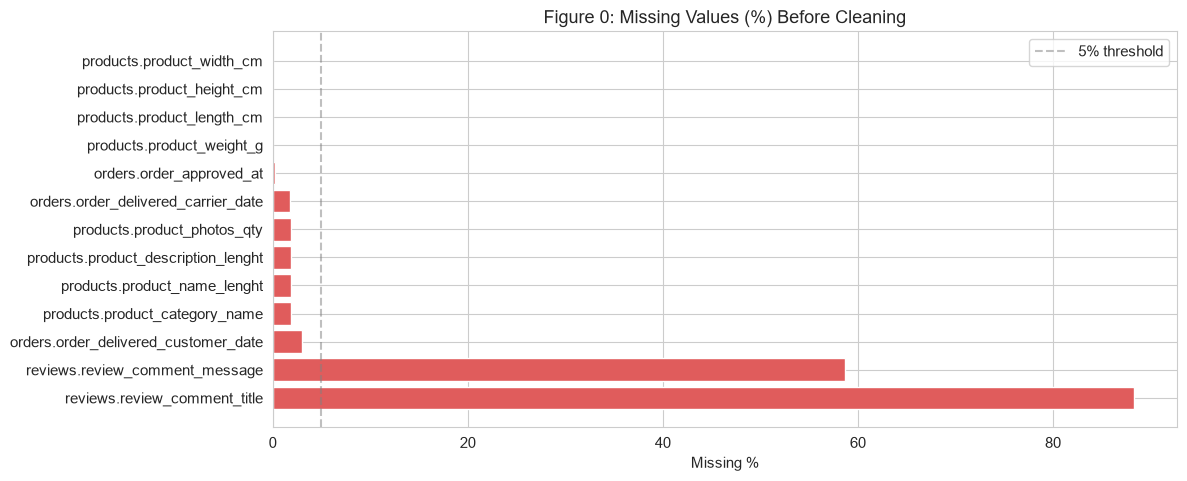

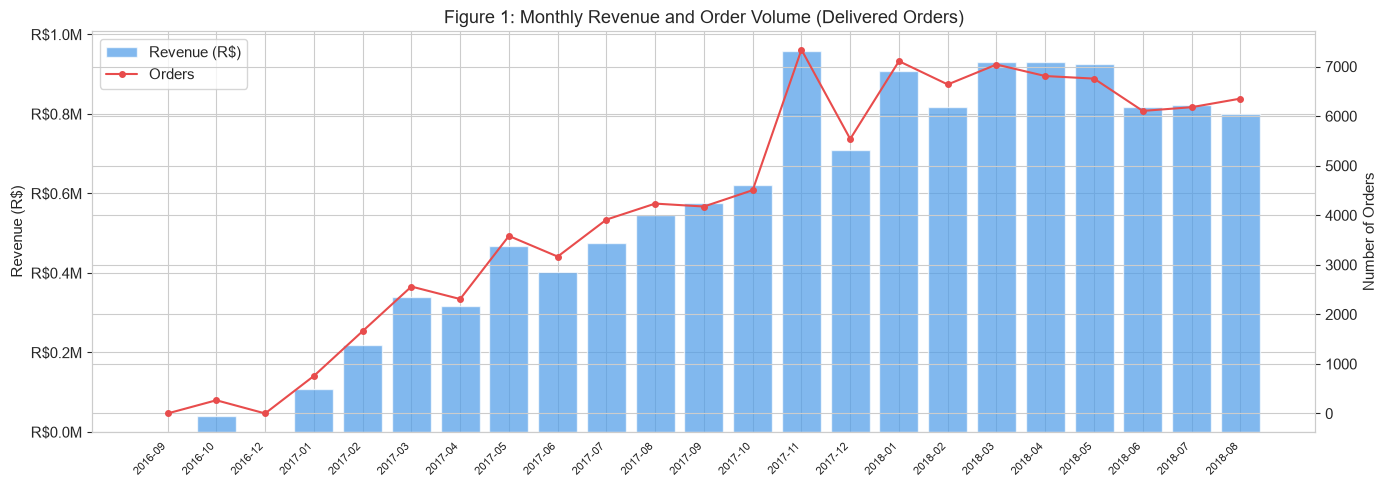

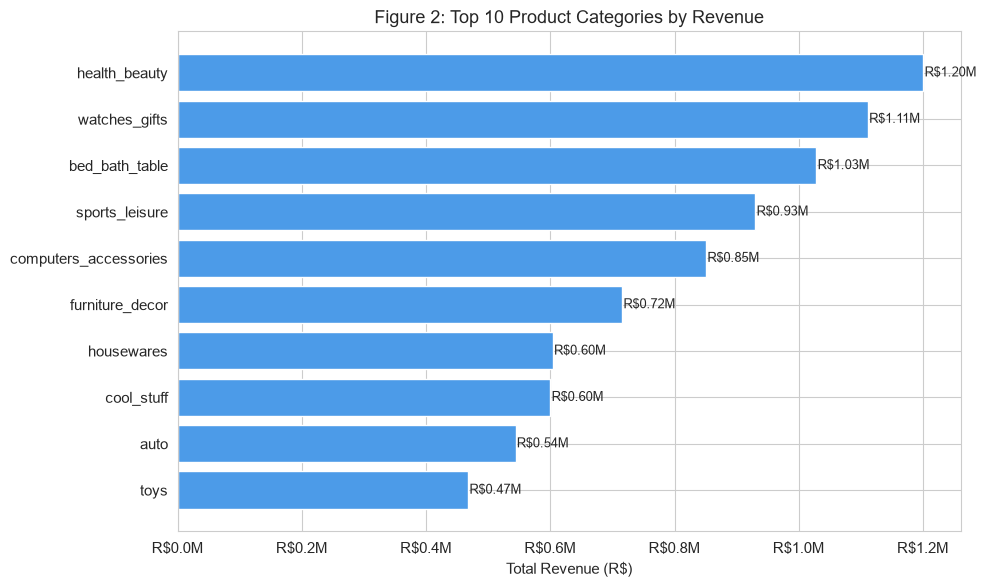

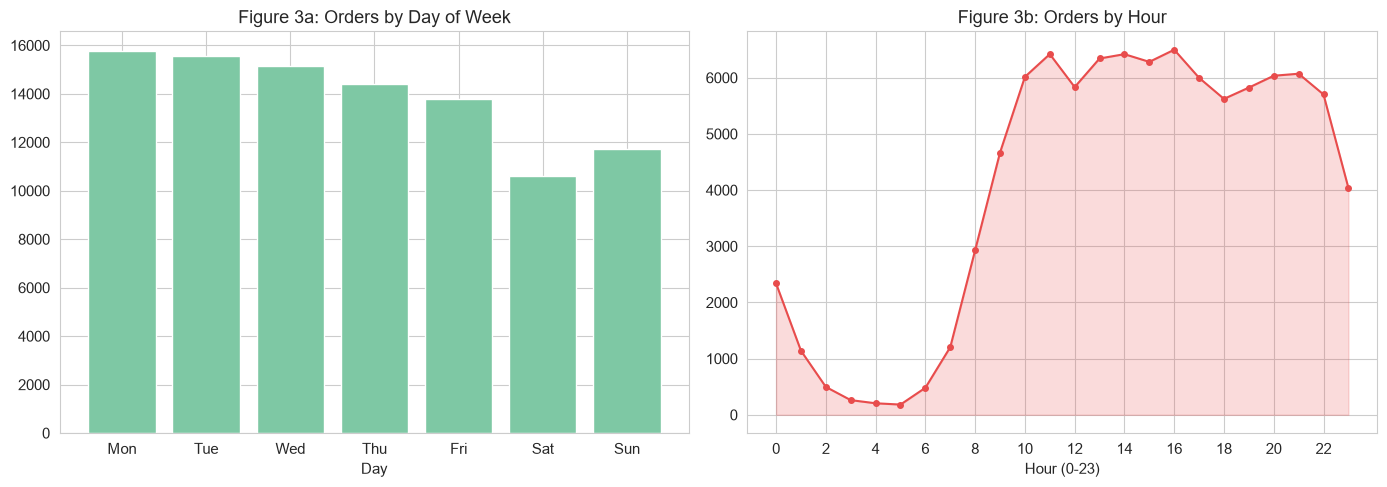

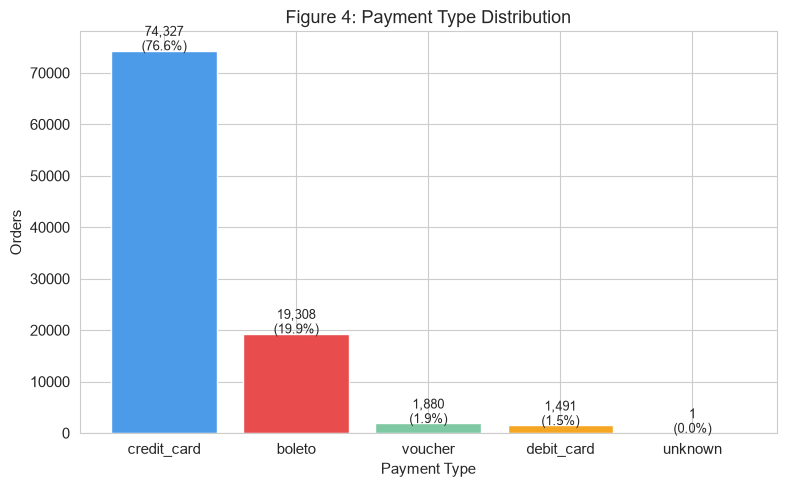

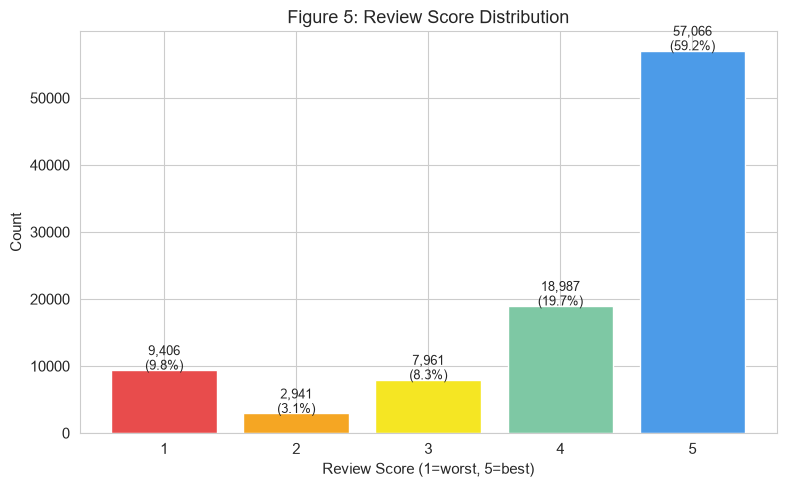

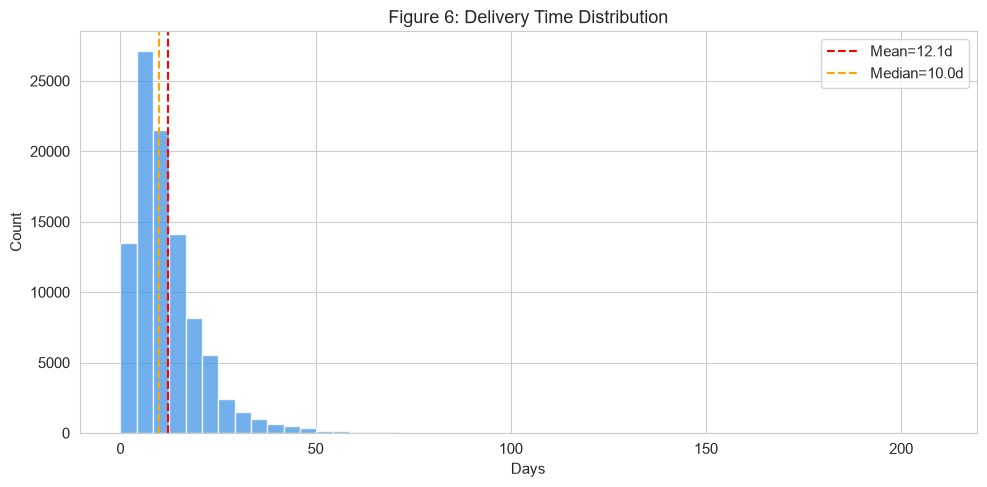

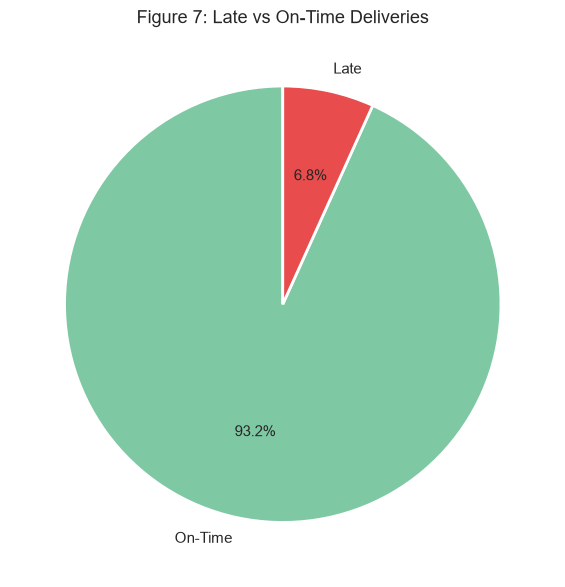

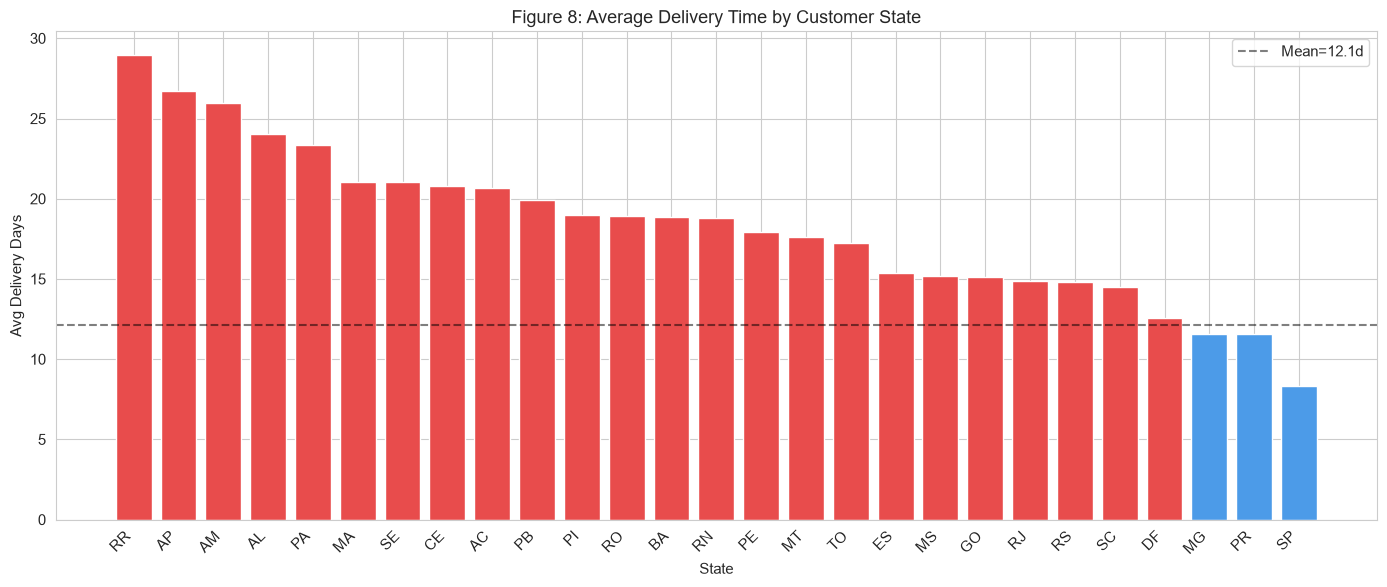

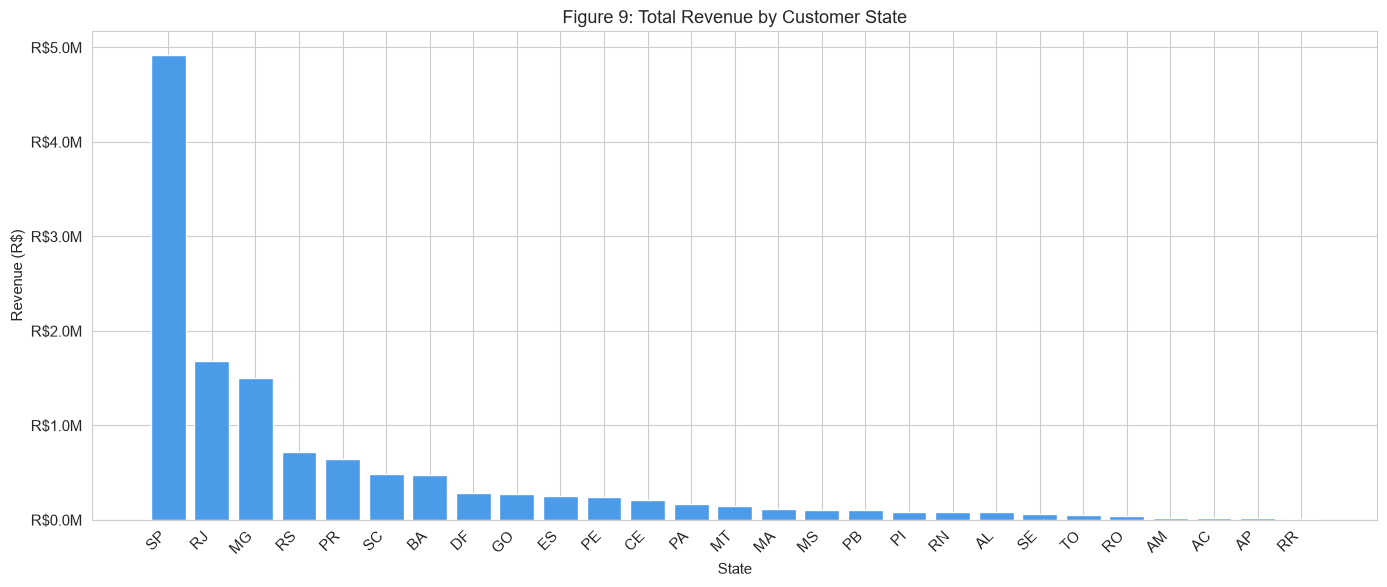

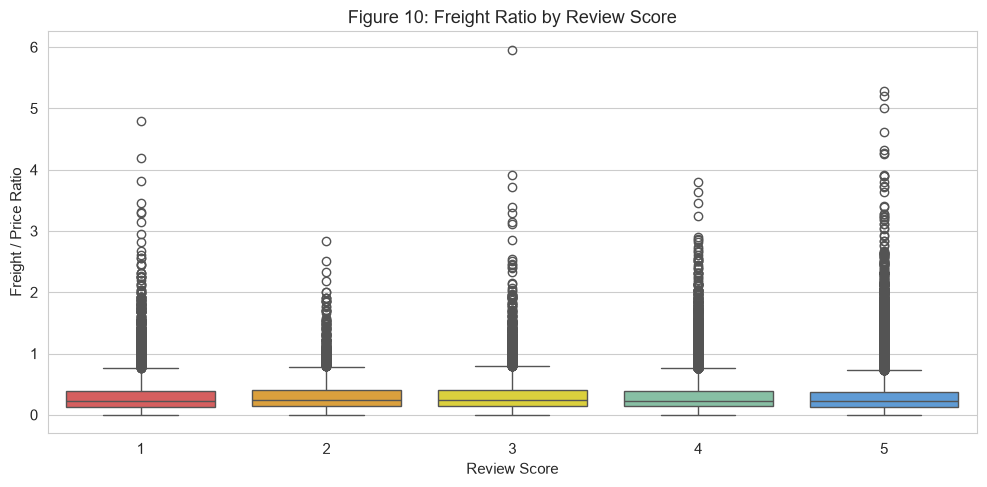

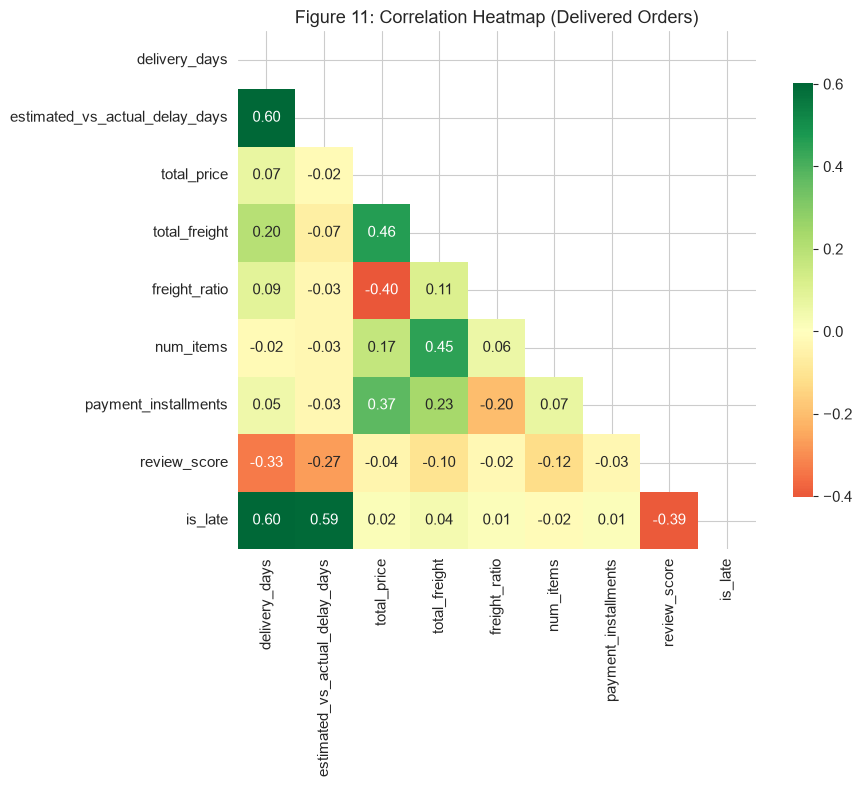

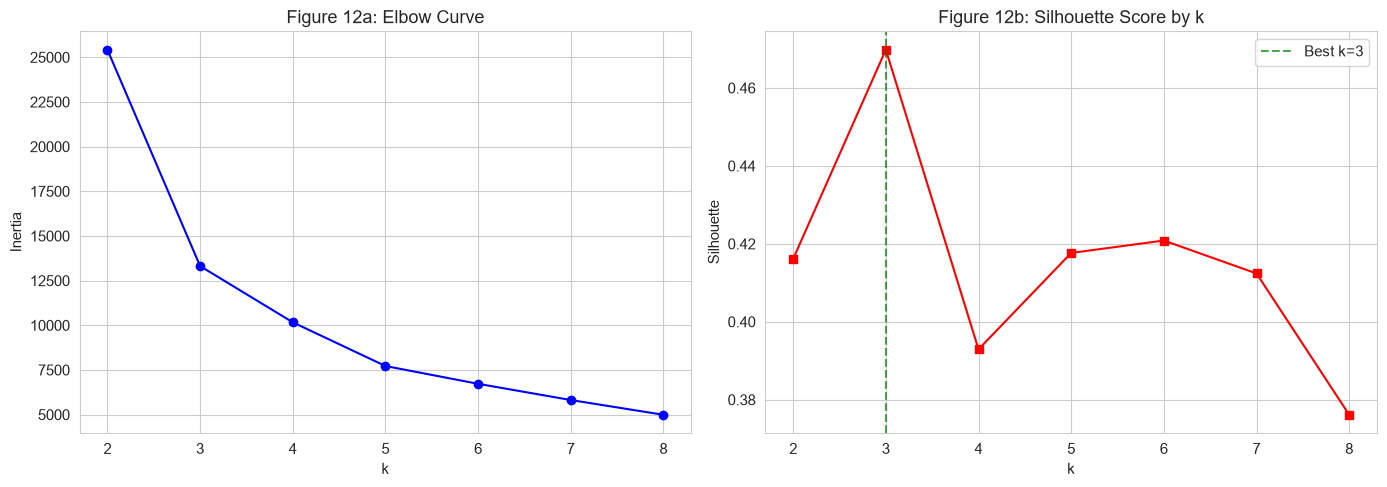

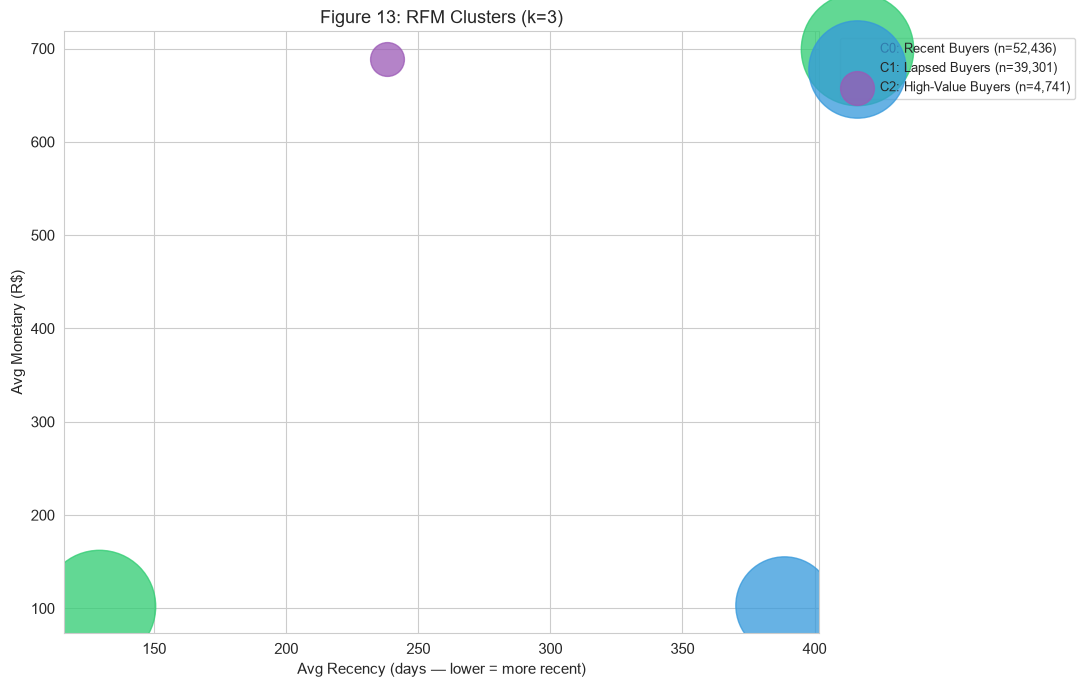

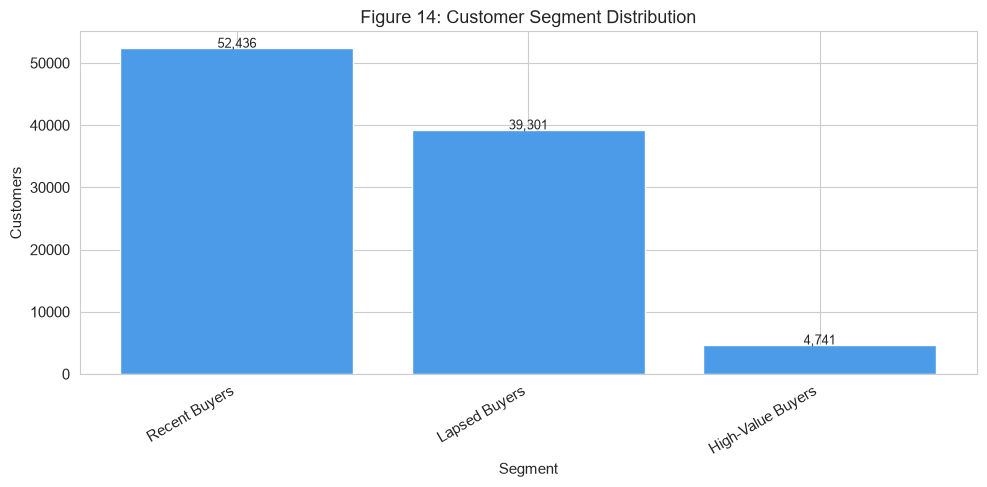

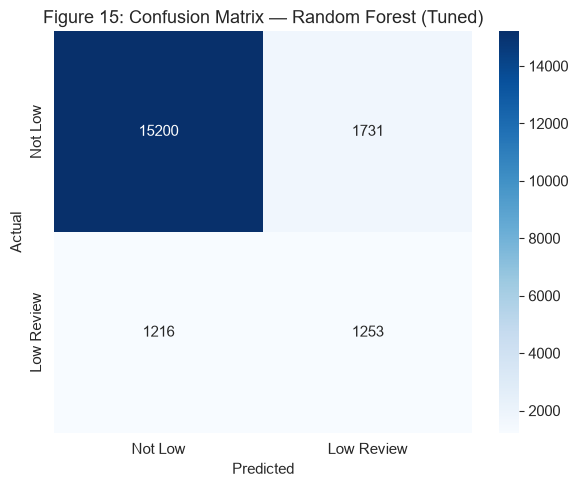

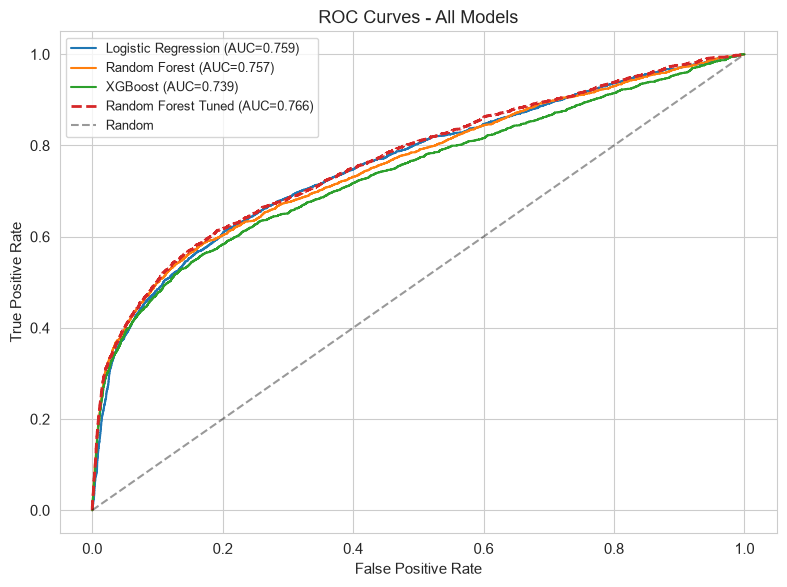

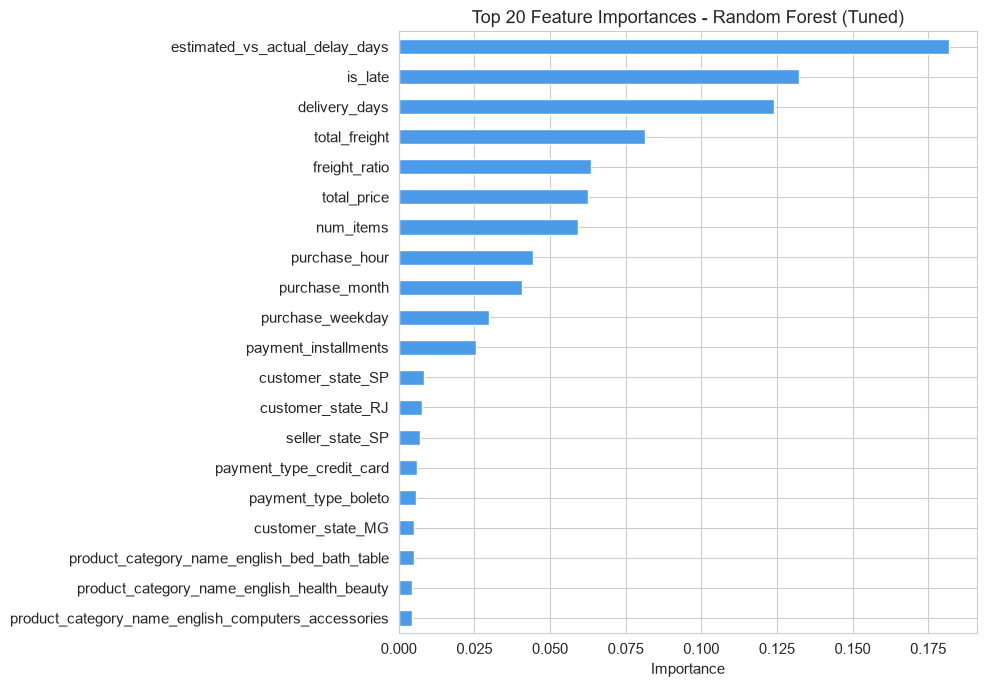

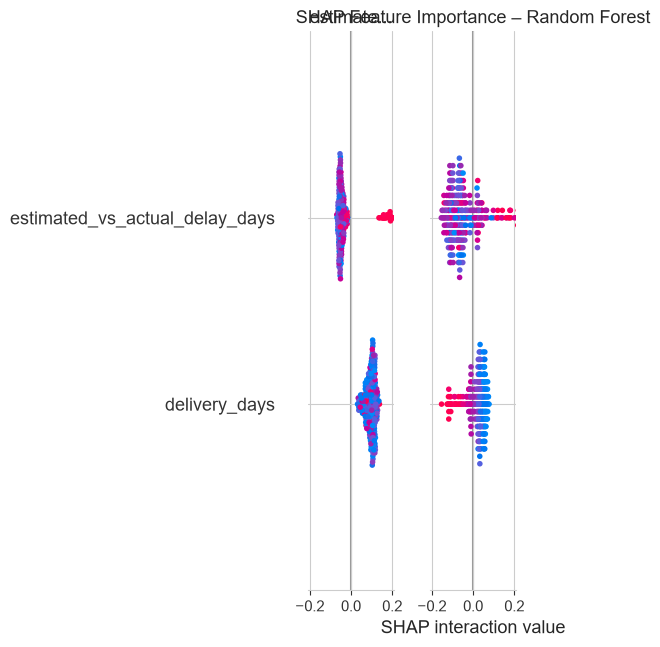

In [29]:
# Show pre-saved figures inline
from IPython.display import Image, display
import os
for fig_file in sorted(os.listdir(FIG_DIR)):
    if fig_file.endswith('.png'):
        display(Image(filename=f'{FIG_DIR}/{fig_file}', width=700))


## J. Business Insights & Recommendations

All numbers below come from the code outputs above.

### 1. Fix Last-Mile Logistics in Slow States  
Late deliveries (6.8% of orders) score a mean of **2.27** vs **4.29** for on-time orders
(Mann-Whitney U p < 0.001, effect r=0.64 — large). State **RR** averages **29 days** delivery
vs the national mean of **12 days**.
**Recommendation:** Establish local fulfilment hubs in the North/Northeast, or negotiate
SLA-based contracts with regional carriers.

### 2. Target the November / Q4 Demand Surge  
Revenue peaked at **R$958,636 in November 2017** (Black Friday effect). Order volume
mirrors this trend.  
**Recommendation:** Pre-position inventory and increase seller capacity in October–November
to prevent late deliveries during the surge — the period when low-review risk is highest.

### 3. Cap High Freight-to-Price Orders  
Low-review orders have a median freight ratio of **0.231** vs **0.223** for high-review.  
**Recommendation:** Alert customers when freight exceeds 25% of item value, and consider
a "freight guarantee" programme for categories with highest ratios.

### 4. Prioritise Top Revenue Categories  
**Health & beauty** leads with **R$1.2M** revenue. The top 10 categories account for the
majority of platform GMV.  
**Recommendation:** Implement category-specific seller quality scores and give these
sellers priority placement and dedicated account management.

### 5. Activate Dormant Customer Segments
The **Lapsed Buyers** cluster (n≈39,301) has high recency (~389 days) but decent
spend — these are churned customers worth re-engaging.
**Recommendation:** Run personalised win-back campaigns (voucher + personalised product
recommendation) targeting this segment via email/push.


## K. Limitations, Future Work & Conclusion

### Limitations
1. Dataset covers only **2016–2018**; post-pandemic delivery dynamics may differ significantly.
2. **Review comment text** (NLP sentiment analysis) was not utilised — could boost model accuracy.
3. **Geolocation** data was loaded but not used for geo-spatial delivery analysis (future work).
4. **96% of customers have frequency=1**, making frequency-based RFM segmentation less
   discriminative than in repeat-purchase contexts. Segments are driven by Recency and Monetary only.
5. **This is a post-delivery model** — it uses actual delivery days and delay features that are
   only known after delivery. It cannot predict bad reviews before dispatch.
6. **ML performance is moderate** (F1=0.46, AUC=0.77). The model is best used as a
   risk-prioritisation tool, not a definitive classifier.

### Future Work
- Real-time prediction API (FastAPI / Flask) calling `models/best_model.joblib`
- NLP sentiment scoring on `review_comment_message`
- Demand forecasting per category per state (ARIMA / Prophet)
- Geo-spatial heatmaps of delivery delays using the geolocation table
- Advanced class-imbalance techniques (SMOTE + Tomek links) and calibrated probabilities

### Conclusion
This project demonstrated that **delivery punctuality is the single most powerful driver
of customer review quality** in the Olist dataset: a large-effect Mann-Whitney U test
(r=0.64, p < 0.001) and Chi-square (V=0.39) both confirm the link. A tuned Random Forest
**post-delivery model** achieved **ROC-AUC=0.77 and F1=0.46** for predicting low reviews —
moderate performance, suitable as a risk-prioritisation tool for order management.
The RFM segmentation identified three customer clusters (High-Value Buyers, Recent Buyers,
Lapsed Buyers), and the business recommendations are directly grounded in the statistical outputs.
